# Logistic Regression for Binary Classification

**Topics:** Binary Classification, Logistic Regression, ROC Curves, Model Evaluation

## Overview

This notebook demonstrates binary classification using logistic regression (binomial GLM with logit link). We'll cover model fitting, interpretation, evaluation metrics, and diagnostic tools.

## What You'll Learn

- Fit logistic regression for binary outcomes
- Interpret coefficients as log-odds and odds ratios
- Compute classification metrics (accuracy, precision, recall)
- Plot ROC curves and compute AUC
- Create confusion matrices
- Visualize decision boundaries
- Check model calibration

---

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from aurora.models import fit_glm
from aurora.validation.metrics import (
    accuracy_score,
    precision,
    recall,
    f1_score,
    roc_auc,
    confusion_matrix
)
from sklearn.metrics import roc_curve

sns.set_style('whitegrid')
np.random.seed(42)

## 2. Generate Classification Data

Simulate customer churn data:
- Binary outcome: churned (1) vs retained (0)
- Predictors: contract length, monthly charges, customer service calls

In [2]:
n = 500

# Generate predictors
contract_length = np.random.uniform(1, 36, n)  # months
monthly_charge = np.random.uniform(20, 150, n)  # dollars
service_calls = np.random.poisson(2, n)  # count

# True log-odds of churn
log_odds = (
    0.5  # baseline
    - 0.08 * contract_length  # longer contract → less churn
    + 0.015 * monthly_charge  # higher charge → more churn
    + 0.3 * service_calls  # more calls → more churn
)

# Convert to probability
prob_churn = 1 / (1 + np.exp(-log_odds))

# Generate binary outcomes
churned = np.random.binomial(1, prob_churn)

# Create DataFrame
df = pd.DataFrame({
    'contract_length': contract_length,
    'monthly_charge': monthly_charge,
    'service_calls': service_calls,
    'churned': churned,
    'prob_churn': prob_churn
})

print(f"Generated data for {n} customers")
print(f"\nChurn rate: {churned.mean()*100:.1f}%")
print(f"Retained: {(1-churned).sum()} customers")
print(f"Churned: {churned.sum()} customers")

print(f"\nSummary by outcome:")
print(df.groupby('churned')[['contract_length', 'monthly_charge', 'service_calls']].mean())

Generated data for 500 customers

Churn rate: 65.6%
Retained: 172 customers
Churned: 328 customers

Summary by outcome:
         contract_length  monthly_charge  service_calls
churned                                                
0              22.909834       72.141538       1.680233
1              16.110788       88.166147       2.250000


## 3. Exploratory Data Analysis

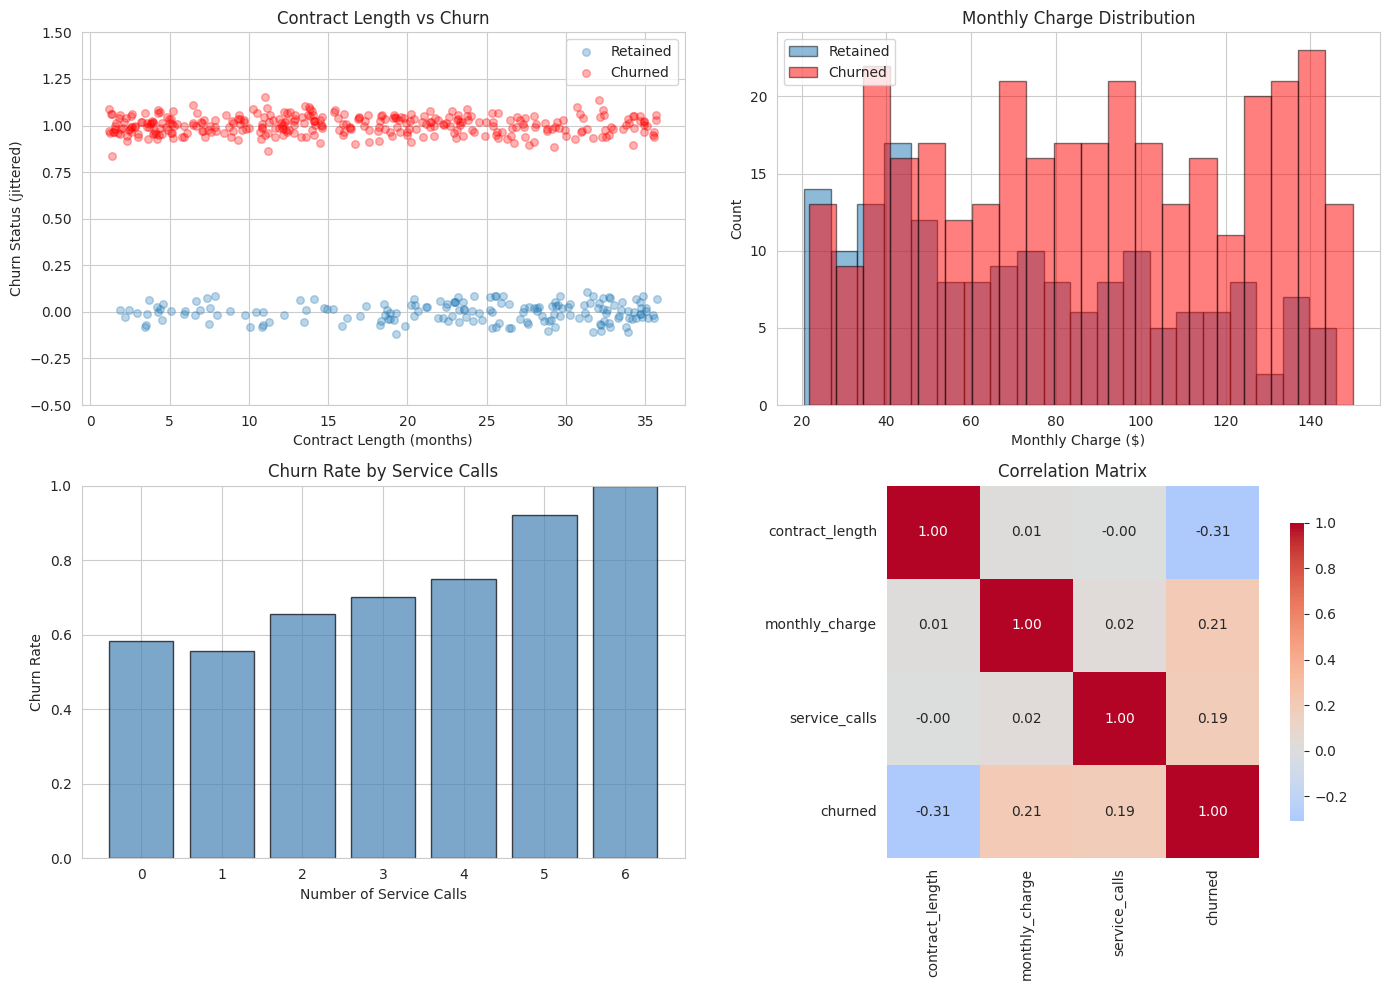

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Contract length vs churn
axes[0, 0].scatter(df[df['churned']==0]['contract_length'], 
                   np.random.randn((df['churned']==0).sum())*0.05,
                   alpha=0.3, label='Retained', s=30)
axes[0, 0].scatter(df[df['churned']==1]['contract_length'], 
                   np.ones((df['churned']==1).sum()) + np.random.randn((df['churned']==1).sum())*0.05,
                   alpha=0.3, label='Churned', s=30, color='red')
axes[0, 0].set_xlabel('Contract Length (months)')
axes[0, 0].set_ylabel('Churn Status (jittered)')
axes[0, 0].set_title('Contract Length vs Churn')
axes[0, 0].legend()
axes[0, 0].set_ylim(-0.5, 1.5)

# Monthly charge distributions
axes[0, 1].hist(df[df['churned']==0]['monthly_charge'], bins=20, 
                alpha=0.5, label='Retained', edgecolor='k')
axes[0, 1].hist(df[df['churned']==1]['monthly_charge'], bins=20, 
                alpha=0.5, label='Churned', edgecolor='k', color='red')
axes[0, 1].set_xlabel('Monthly Charge ($)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Monthly Charge Distribution')
axes[0, 1].legend()

# Service calls
service_call_churn = df.groupby('service_calls')['churned'].agg(['mean', 'count'])
axes[1, 0].bar(service_call_churn.index, service_call_churn['mean'], 
               alpha=0.7, edgecolor='k', color='steelblue')
axes[1, 0].set_xlabel('Number of Service Calls')
axes[1, 0].set_ylabel('Churn Rate')
axes[1, 0].set_title('Churn Rate by Service Calls')
axes[1, 0].set_ylim(0, 1)

# Correlation heatmap
corr = df[['contract_length', 'monthly_charge', 'service_calls', 'churned']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, ax=axes[1, 1], cbar_kws={'shrink': 0.8})
axes[1, 1].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

## 4. Fit Logistic Regression

Fit binomial GLM with logit link:

In [4]:
# Design matrix (without manual intercept - let fit_glm add it)
X = np.column_stack([
    df['contract_length'],
    df['monthly_charge'],
    df['service_calls']
])
y = df['churned'].values

# Fit logistic regression (fit_intercept=True by default)
result = fit_glm(
    X=X,
    y=y,
    family='binomial'
)

print(f"Model converged: {result.converged_}")
print(f"Iterations: {result.n_iter_}")
print(f"\n" + "="*60)
print(result.summary())
print("="*60)

Model converged: True
Iterations: 4

                       Generalized Linear Model Results                       
Family:                   Binomial                   Link function:  Logit
No. Observations:         500                        Df Residuals:   496
Df Model:                 3                         
Converged:                Yes                        No. Iterations: 4
                   coef    std err          z      P>|z|     [0.025     0.975]
------------------------------------------------------------------------------
   intercept     0.2469     0.3398      0.727      0.467    -0.4191     0.9129 
          X0    -0.0744     0.0107     -6.967      0.000    -0.0953    -0.0535 ***
          X1     0.0143     0.0030      4.855      0.000     0.0085     0.0201 ***
          X2     0.3611     0.0808      4.467      0.000     0.2026     0.5195 ***
Significance codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Deviance:                               547.71 Null Devian

## 5. Interpret Coefficients

### Log-Odds and Odds Ratios


Coefficient Interpretation:
      Predictor  True Log-Odds  Estimated Log-Odds  Odds Ratio      p-value  Significant
      Intercept          0.500            0.246901    1.280052 4.674390e-01        False
Contract Length         -0.080           -0.074380    0.928319 3.240519e-12         True
 Monthly Charge          0.015            0.014332    1.014435 1.205500e-06         True
  Service Calls          0.300            0.361078    1.434875 7.949682e-06         True

📊 Interpretation:

1. Contract Length (β = -0.0744):
   • OR = 0.9283
   • Each additional month → 7.2% decrease in churn odds

2. Monthly Charge (β = 0.0143):
   • OR = 1.0144
   • Each additional $1 → 1.4% increase in churn odds

3. Service Calls (β = 0.3611):
   • OR = 1.4349
   • Each additional call → 43.5% increase in churn odds


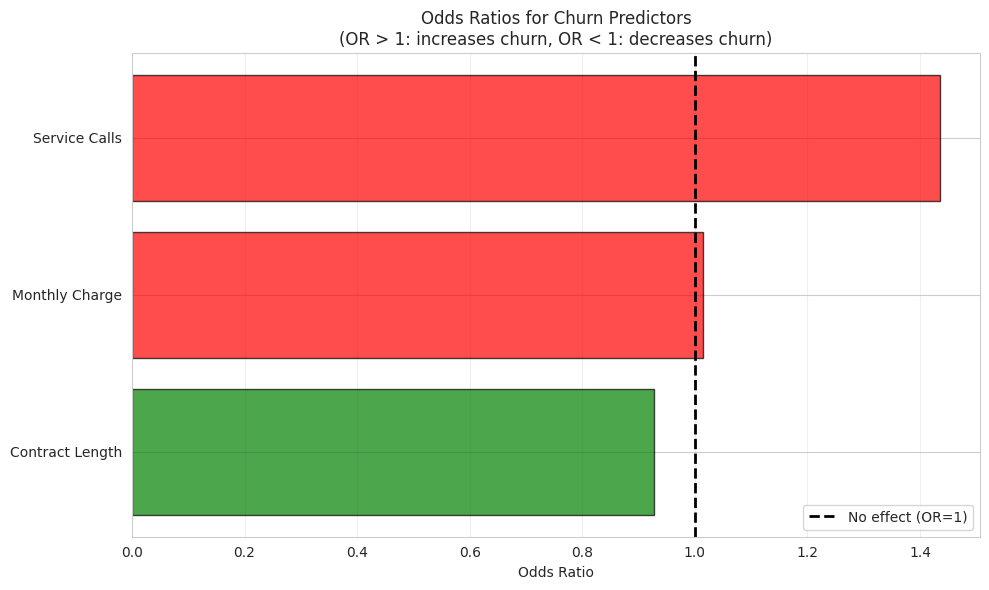

In [5]:
coef_names = ['Intercept', 'Contract Length', 'Monthly Charge', 'Service Calls']
true_coefs = [0.5, -0.08, 0.015, 0.3]

# Combine intercept and coefficients for comparison
if result.intercept_ is not None:
    coefficients_full = np.concatenate([[result.intercept_], result.coef_])
    p_values_full = np.concatenate([[result.intercept_p_value_], result.p_values_])
else:
    coefficients_full = result.coef_
    p_values_full = result.p_values_

# Odds ratios (exp of coefficients)
odds_ratios = np.exp(coefficients_full)
true_odds_ratios = np.exp(true_coefs)

interpretation_df = pd.DataFrame({
    'Predictor': coef_names,
    'True Log-Odds': true_coefs,
    'Estimated Log-Odds': coefficients_full,
    'Odds Ratio': odds_ratios,
    'p-value': p_values_full,
    'Significant': p_values_full < 0.05
})

print("\nCoefficient Interpretation:")
print(interpretation_df.to_string(index=False))

print("\n📊 Interpretation:")
print(f"\n1. Contract Length (β = {result.coef_[0]:.4f}):")
print(f"   • OR = {odds_ratios[1]:.4f}")
print(f"   • Each additional month → {(1-odds_ratios[1])*100:.1f}% decrease in churn odds")
print(f"\n2. Monthly Charge (β = {result.coef_[1]:.4f}):")
print(f"   • OR = {odds_ratios[2]:.4f}")
print(f"   • Each additional $1 → {(odds_ratios[2]-1)*100:.1f}% increase in churn odds")
print(f"\n3. Service Calls (β = {result.coef_[2]:.4f}):")
print(f"   • OR = {odds_ratios[3]:.4f}")
print(f"   • Each additional call → {(odds_ratios[3]-1)*100:.1f}% increase in churn odds")

# Visualize odds ratios
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(1, len(coef_names))  # Exclude intercept

ax.barh(y_pos, odds_ratios[1:], alpha=0.7, color=['green' if or_val < 1 else 'red' 
                                                    for or_val in odds_ratios[1:]], edgecolor='k')
ax.axvline(1, color='black', linestyle='--', linewidth=2, label='No effect (OR=1)')
ax.set_yticks(y_pos)
ax.set_yticklabels(coef_names[1:])
ax.set_xlabel('Odds Ratio')
ax.set_title('Odds Ratios for Churn Predictors\n(OR > 1: increases churn, OR < 1: decreases churn)')
ax.legend()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 6. Make Predictions

In [6]:
# Predicted probabilities
prob_pred = result.predict(X)

# Convert to binary predictions (threshold = 0.5)
y_pred = (prob_pred >= 0.5).astype(int)

# Add to DataFrame
df['prob_pred'] = prob_pred
df['churn_pred'] = y_pred

print("\nPrediction examples:")
print(df[['contract_length', 'monthly_charge', 'service_calls', 
          'churned', 'prob_pred', 'churn_pred']].head(10).to_string(index=False))


Prediction examples:
 contract_length  monthly_charge  service_calls  churned  prob_pred  churn_pred
       14.108904      110.761023              1        0   0.758769           1
       34.275001       89.692528              6        1   0.759409           1
       26.619788       60.238590              1        1   0.375503           0
       21.953047      125.793353              2        1   0.757499           1
        6.460652      109.015052              2        1   0.886036           1
        6.459808       41.140202              2        1   0.746150           1
        3.032926      138.420534              5        1   0.978342           1
       31.316165      126.929842              4        1   0.765133           1
       22.039025      143.473989              2        0   0.799955           1
       25.782540      114.343536              0        0   0.491983           0


## 7. Evaluate Model Performance

### Confusion Matrix

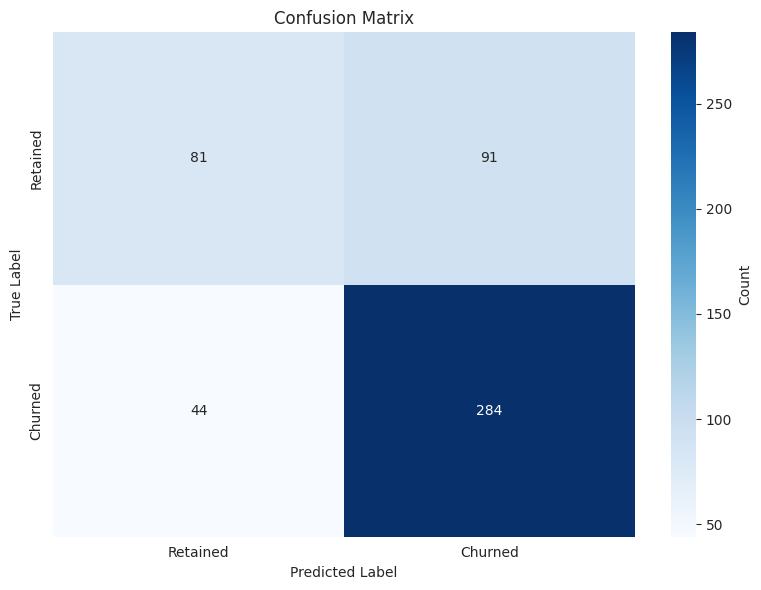


Confusion Matrix Breakdown:
  True Negatives (TN):   81  (Correctly predicted retained)
  False Positives (FP):  91  (Incorrectly predicted churned)
  False Negatives (FN):  44  (Incorrectly predicted retained)
  True Positives (TP):  284  (Correctly predicted churned)


In [7]:
# Compute confusion matrix
cm = confusion_matrix(y, y_pred)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'],
            cbar_kws={'label': 'Count'}, ax=ax)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Extract values
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix Breakdown:")
print(f"  True Negatives (TN):  {tn:>3d}  (Correctly predicted retained)")
print(f"  False Positives (FP): {fp:>3d}  (Incorrectly predicted churned)")
print(f"  False Negatives (FN): {fn:>3d}  (Incorrectly predicted retained)")
print(f"  True Positives (TP):  {tp:>3d}  (Correctly predicted churned)")

### Classification Metrics


Classification Metrics:
   Metric    Value                               Interpretation
 Accuracy 0.730000                          Overall correctness
Precision 0.757333      Of predicted churns, % actually churned
   Recall 0.865854      Of actual churns, % correctly predicted
 F1-Score 0.807966          Harmonic mean of precision & recall
  ROC-AUC 0.755229 Probability of ranking churner > non-churner


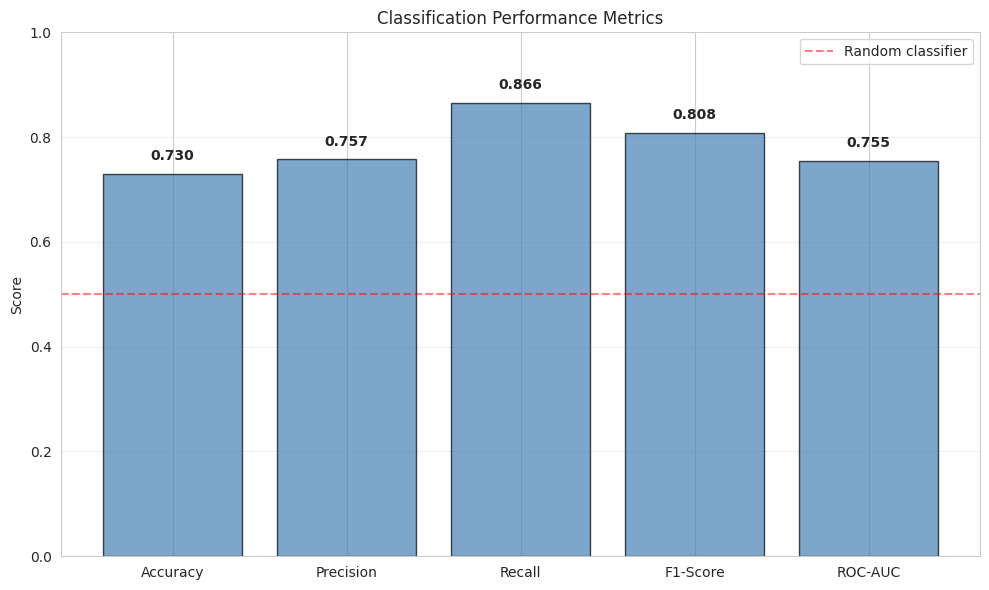

In [8]:
# Compute metrics
acc = accuracy_score(y, y_pred)
prec = precision(y, y_pred)
rec = recall(y, y_pred)
f1 = f1_score(y, y_pred)
auc = roc_auc(y, prob_pred)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Value': [acc, prec, rec, f1, auc],
    'Interpretation': [
        'Overall correctness',
        'Of predicted churns, % actually churned',
        'Of actual churns, % correctly predicted',
        'Harmonic mean of precision & recall',
        'Probability of ranking churner > non-churner'
    ]
})

print("\nClassification Metrics:")
print(metrics_df.to_string(index=False))

# Visualize metrics
fig, ax = plt.subplots(figsize=(10, 6))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
values = [acc, prec, rec, f1, auc]

bars = ax.bar(metrics_to_plot, values, alpha=0.7, edgecolor='k', color='steelblue')
ax.set_ylabel('Score')
ax.set_title('Classification Performance Metrics')
ax.set_ylim(0, 1)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Random classifier')
ax.legend()
ax.grid(alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. ROC Curve

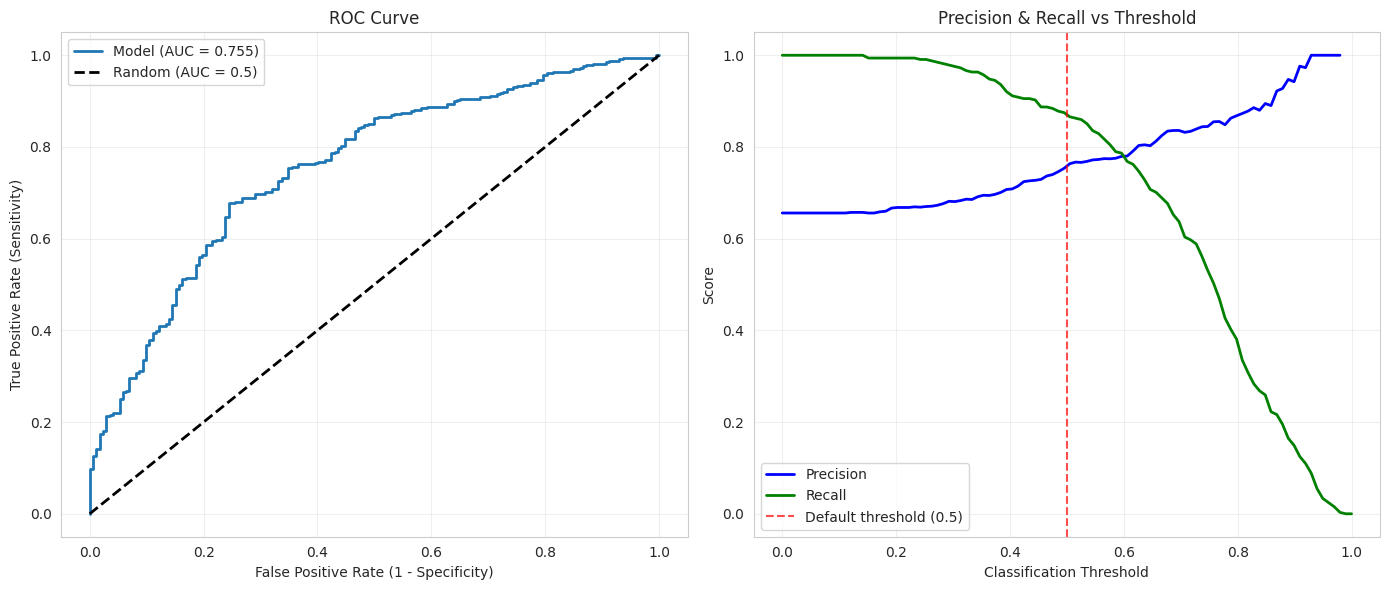


→ AUC = 0.755 indicates fair discrimination


In [9]:
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y, prob_pred)

# Plot ROC curve
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: ROC curve
axes[0].plot(fpr, tpr, lw=2, label=f'Model (AUC = {auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.5)')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim([-0.05, 1.05])
axes[0].set_ylim([-0.05, 1.05])

# Right: Precision-Recall vs Threshold
precision_curve = []
recall_curve = []
thresholds_eval = np.linspace(0, 1, 100)

for thresh in thresholds_eval:
    y_pred_thresh = (prob_pred >= thresh).astype(int)
    if y_pred_thresh.sum() > 0:  # Avoid division by zero
        precision_curve.append(precision(y, y_pred_thresh))
        recall_curve.append(recall(y, y_pred_thresh))
    else:
        precision_curve.append(np.nan)
        recall_curve.append(0)

axes[1].plot(thresholds_eval, precision_curve, lw=2, label='Precision', color='blue')
axes[1].plot(thresholds_eval, recall_curve, lw=2, label='Recall', color='green')
axes[1].axvline(0.5, color='red', linestyle='--', alpha=0.7, label='Default threshold (0.5)')
axes[1].set_xlabel('Classification Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision & Recall vs Threshold')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_ylim([-0.05, 1.05])

plt.tight_layout()
plt.show()

print(f"\n→ AUC = {auc:.3f} indicates {'excellent' if auc > 0.9 else 'good' if auc > 0.8 else 'fair'} discrimination")

## 9. Decision Boundaries

Visualize decision boundaries in 2D (fixing other variables):

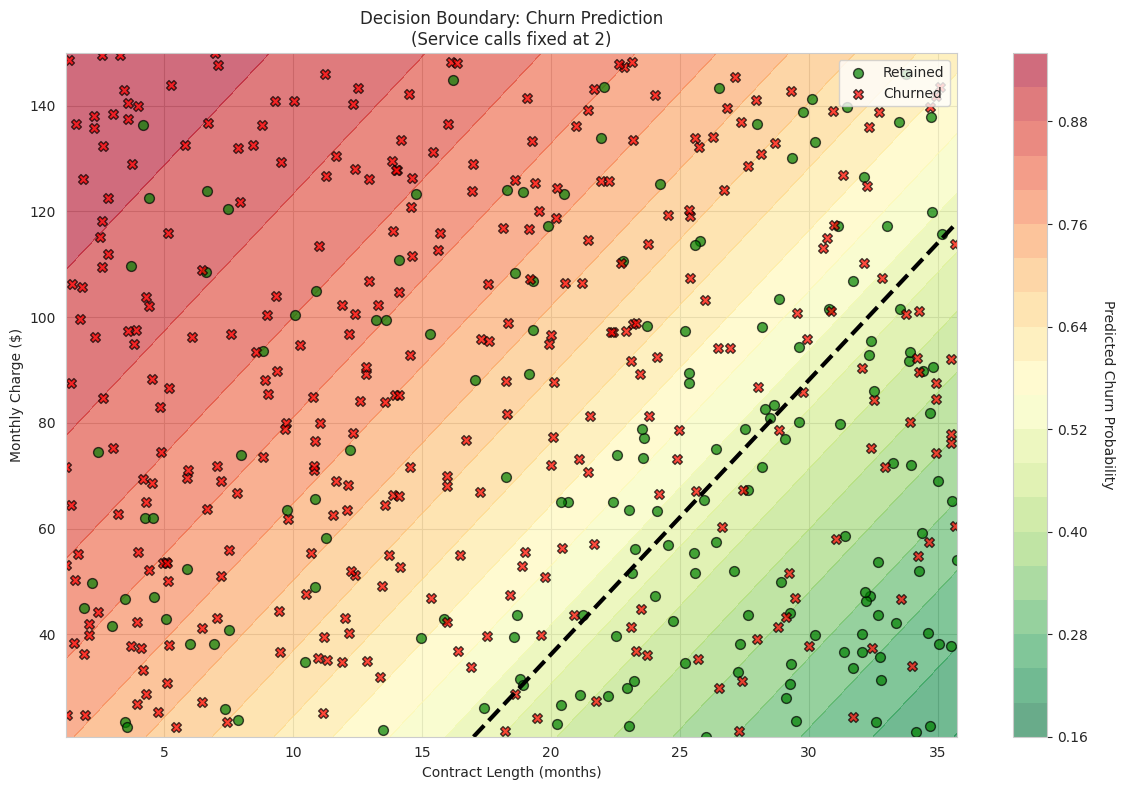


Decision boundary (black dashed line) at P(churn) = 0.5
Points above/right of line predicted to churn
Points below/left of line predicted to be retained


In [10]:
# Create grid for decision boundary (contract_length vs monthly_charge)
contract_range = np.linspace(df['contract_length'].min(), df['contract_length'].max(), 100)
charge_range = np.linspace(df['monthly_charge'].min(), df['monthly_charge'].max(), 100)
contract_grid, charge_grid = np.meshgrid(contract_range, charge_range)

# Fix service_calls at median
service_calls_fixed = df['service_calls'].median()

# Predict on grid (no manual intercept - model adds it)
grid_points = np.column_stack([
    contract_grid.ravel(),
    charge_grid.ravel(),
    np.full(contract_grid.size, service_calls_fixed)
])
prob_grid = result.predict(grid_points).reshape(contract_grid.shape)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

# Contour plot of probabilities
contour = ax.contourf(contract_grid, charge_grid, prob_grid, levels=20, 
                       cmap='RdYlGn_r', alpha=0.6)
ax.contour(contract_grid, charge_grid, prob_grid, levels=[0.5], 
           colors='black', linewidths=3, linestyles='--')

# Scatter actual data points
ax.scatter(df[df['churned']==0]['contract_length'], 
           df[df['churned']==0]['monthly_charge'],
           c='green', marker='o', s=50, edgecolor='k', alpha=0.7, label='Retained')
ax.scatter(df[df['churned']==1]['contract_length'], 
           df[df['churned']==1]['monthly_charge'],
           c='red', marker='X', s=50, edgecolor='k', alpha=0.7, label='Churned')

ax.set_xlabel('Contract Length (months)')
ax.set_ylabel('Monthly Charge ($)')
ax.set_title(f'Decision Boundary: Churn Prediction\n(Service calls fixed at {service_calls_fixed:.0f})')
ax.legend(loc='upper right')

# Add colorbar
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('Predicted Churn Probability', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()

print("\nDecision boundary (black dashed line) at P(churn) = 0.5")
print("Points above/right of line predicted to churn")
print("Points below/left of line predicted to be retained")

## 10. Model Calibration

Check if predicted probabilities match observed frequencies:

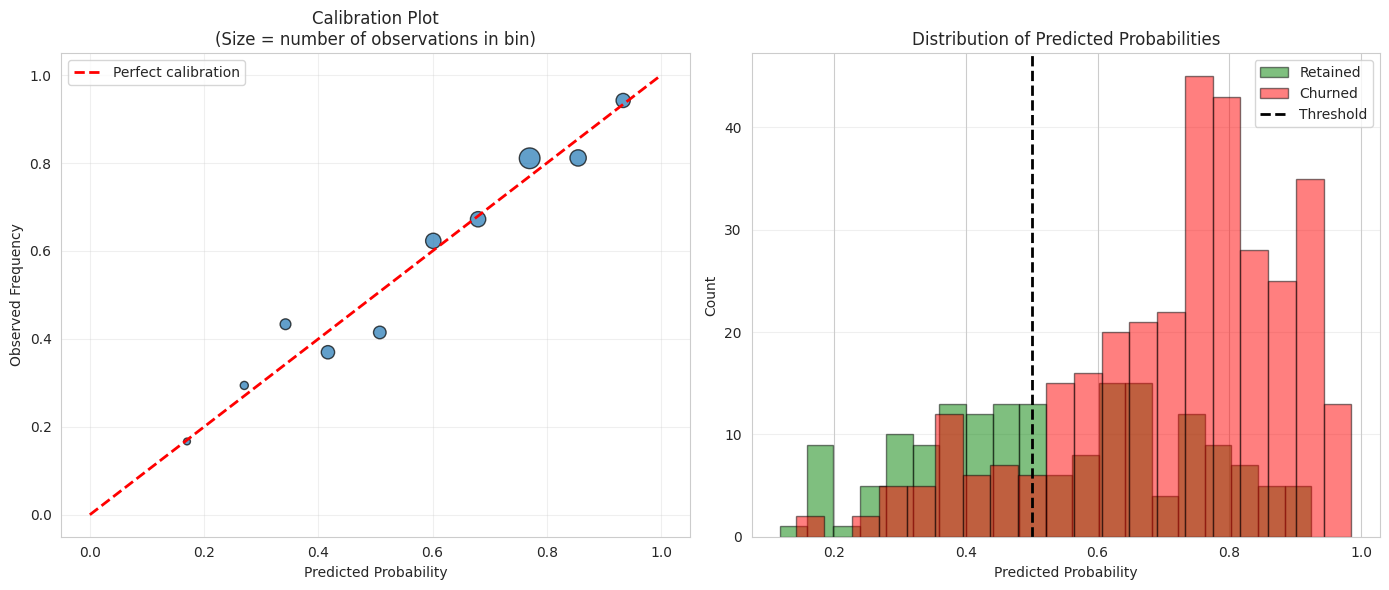


Well-calibrated model: points fall close to diagonal line
Separation in probability distributions shows good discrimination


In [11]:
# Bin predictions and compute observed frequencies
n_bins = 10
df['prob_bin'] = pd.cut(df['prob_pred'], bins=n_bins)

calibration_data = df.groupby('prob_bin', observed=True).agg({
    'prob_pred': 'mean',
    'churned': 'mean',
    'contract_length': 'count'
}).rename(columns={'contract_length': 'count'})

# Plot calibration curve
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Calibration plot
axes[0].scatter(calibration_data['prob_pred'], calibration_data['churned'], 
                s=calibration_data['count']*2, alpha=0.7, edgecolor='k')
axes[0].plot([0, 1], [0, 1], 'r--', lw=2, label='Perfect calibration')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Observed Frequency')
axes[0].set_title('Calibration Plot\n(Size = number of observations in bin)')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim([-0.05, 1.05])
axes[0].set_ylim([-0.05, 1.05])

# Right: Histogram of predicted probabilities
axes[1].hist(df[df['churned']==0]['prob_pred'], bins=20, alpha=0.5, 
             label='Retained', edgecolor='k', color='green')
axes[1].hist(df[df['churned']==1]['prob_pred'], bins=20, alpha=0.5, 
             label='Churned', edgecolor='k', color='red')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Predicted Probabilities')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nWell-calibrated model: points fall close to diagonal line")
print("Separation in probability distributions shows good discrimination")

## Key Concepts

- **Log-odds**: β₀ + β₁x₁ + ... (linear predictor)
- **Odds ratio**: exp(β) = multiplicative effect on odds
- **Probability**: P(y=1) = 1 / (1 + exp(-log_odds))
- **ROC-AUC**: Area under ROC curve (discrimination ability)
- **Threshold selection**: Balance precision vs recall based on business needs

## Best Practices

1. **Always check calibration** - Predicted probabilities should match reality
2. **Report multiple metrics** - Accuracy alone can be misleading
3. **Choose threshold carefully** - Default 0.5 may not be optimal
4. **Visualize decision boundaries** - Helps interpret model behavior
5. **Check for imbalance** - Use stratified sampling or reweighting if needed

## Next Steps

- **Multi-class classification:** See `02_classification/02_multinomial_classification.ipynb`
- **Non-linear boundaries:** See `02_classification/03_gam_classification.ipynb`
- **Count data:** See `03_count_data/01_poisson_regression.ipynb`

## Resources

- [Aurora-GLM Documentation](https://github.com/Matcraft94/Aurora-GLM)
- [Logistic Regression (Wikipedia)](https://en.wikipedia.org/wiki/Logistic_regression)
- [Understanding ROC Curves](https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc)